# HVM MultiHeadTransformerV2 Sweep Results
Loads current `checkpoints/multihead_v2/hvm_v2/*/best.pt` results and visualises performance.

Targets: **global SigLIP (1152-d)**, **obj SigLIP (1152-d)**, **CLIP-short (768-d)**.

Primary metric: **mean cosine similarity** `(cos_sg + cos_so + cos_clip) / 3`. SigLIP heads use InfoNCE + cosine loss (`nce_weight=0.1`, fixed). CLIP head uses cosine only; 2-AFC is reported for the two SigLIP heads.

Current `predict` runs are the retrained post-hoc classifier setup: embedding heads train with GT category conditioning, then the category decoder trains on the frozen neural embedding. Legacy `predict` checkpoints without `wrong_cat_prob` are excluded by the loader.


In [12]:

import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR

# Current sweep schema:
#   predict runs are the post-hoc classifier retrains with clf_* args and wrong_cat_prob.
#   legacy predict runs without wrong_cat_prob are intentionally excluded below.
SWEEP_AXES = ['cat_mode', 'd_model', 'n_layers', 'shared_dim', 'wrong_cat_prob']
SWEEP_DIR  = CHECKPOINT_DIR / 'multihead_v2' / 'hvm_v2'


def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception as exc:
        return {'path': str(pt), '_load_error': repr(exc)}

    args = ckpt.get('args', {})
    metrics = ckpt.get('metrics', {})
    row = {**args, **metrics, 'path': str(pt), 'epoch': ckpt.get('epoch', metrics.get('epoch'))}

    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])

    # New predict-mode retrains save classifier metrics after the embedding heads finish.
    posthoc = ckpt.get('posthoc_cat_metrics', {}) or {}
    if posthoc:
        row['posthoc_val_cat_acc'] = posthoc.get('val_cat_acc', np.nan)
        row['posthoc_train_cat_acc'] = posthoc.get('train_cat_acc', np.nan)

    # A single display column for category decoder val accuracy.
    row['classifier_val_acc'] = row.get('posthoc_val_cat_acc', row.get('val_cat_acc', np.nan))
    row['classifier_test_acc'] = row.get('test_cat_acc', np.nan)

    cat_mode = row.get('cat_mode')
    has_current_predict_fields = ('wrong_cat_prob' in row) and ('clf_epochs' in row)
    row['result_schema'] = (
        'current_predict' if cat_mode == 'predict' and has_current_predict_fields else
        'legacy_predict' if cat_mode == 'predict' else
        'given'
    )
    return row


candidates = sorted(SWEEP_DIR.glob('*/best.pt'))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row and '_load_error' not in row:
            records.append(row)

df_all = pd.DataFrame(records)
if df_all.empty:
    raise RuntimeError(f'No checkpoints found in {SWEEP_DIR}')

# Keep current predict retrains plus given baselines. Drop old predict checkpoints from before
# post-hoc classifier/wrong_cat_prob existed so plots reflect the latest model definition.
df = df_all[df_all['result_schema'].isin(['current_predict', 'given'])].copy()

has_test = 'test_cos_siglip_global' in df.columns and df['test_cos_siglip_global'].notna().any()

for col in ['d_model', 'n_layers', 'shared_dim', 'wrong_cat_prob', 'clf_epochs', 'clf_lr']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

SORT_BY = 'val_mean_cos'
show_cols = SWEEP_AXES + [
    'val_mean_cos', 'val_mean_2afc',
    'val_cos_siglip_global', 'val_cos_siglip_obj', 'val_cos_clip',
    'val_2afc_siglip_global', 'val_2afc_siglip_obj',
    'classifier_val_acc', 'classifier_test_acc',
    'result_schema', 'path',
]
show_cols = [c for c in show_cols if c in df.columns]

print(f'{len(df)} current runs loaded from {SWEEP_DIR}  |  test metrics present: {has_test}')
print('All schemas found:')
print(df_all['result_schema'].value_counts(dropna=False).to_string())
print('\nCurrent result table:')
print(df[show_cols].sort_values(SORT_BY, ascending=False).to_string(index=False))


Loading:   0%|          | 0/48 [00:00<?, ?it/s]

36 current runs loaded from /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2  |  test metrics present: True
All schemas found:
result_schema
current_predict    24
given              12
legacy_predict     12

Current result table:
cat_mode  d_model  n_layers  shared_dim  wrong_cat_prob  val_mean_cos  val_mean_2afc  val_cos_siglip_global  val_cos_siglip_obj  val_cos_clip  val_2afc_siglip_global  val_2afc_siglip_obj  classifier_val_acc  classifier_test_acc   result_schema                                                                                                                                                                                                                  path
 predict       64         2         512             0.0      0.903606       0.959176               0.854909            0.871176      0.984734                0.961174             0.957179            0.277778             0.222222 current_predict  /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v

## Best run per cat_mode

In [13]:

cols = ['cat_mode', 'wrong_cat_prob', 'd_model', 'n_layers', 'shared_dim',
        'val_mean_cos', 'val_mean_2afc',
        'val_cos_siglip_global', 'val_cos_siglip_obj', 'val_cos_clip',
        'val_2afc_siglip_global', 'val_2afc_siglip_obj',
        'classifier_val_acc', 'classifier_test_acc']
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values('val_mean_cos', ascending=False)
      .groupby(['cat_mode', 'wrong_cat_prob'], sort=True, dropna=False)
      .first()
      .reset_index()
)[available]
display(summary)


,cat_mode,wrong_cat_prob,d_model,n_layers,shared_dim,val_mean_cos,val_mean_2afc,val_cos_siglip_global,val_cos_siglip_obj,val_cos_clip,val_2afc_siglip_global,val_2afc_siglip_obj,classifier_val_acc,classifier_test_acc
0,given,NaN,64,2,512,0.902382,0.959551,0.854023,0.869082,0.984039,0.962297,0.956804,NaN,NaN
1,predict,0.0,64,2,512,0.903606,0.959176,0.854909,0.871176,0.984734,0.961174,0.957179,0.277778,0.222222
2,predict,0.1,128,2,256,0.896247,0.952809,0.858108,0.867941,0.962693,0.953933,0.951685,0.322222,0.311111


## Per-head cosine similarity and 2-AFC by sweep axis
Points coloured by `cat_mode`; horizontal bars show the mean across all other hyperparameters.

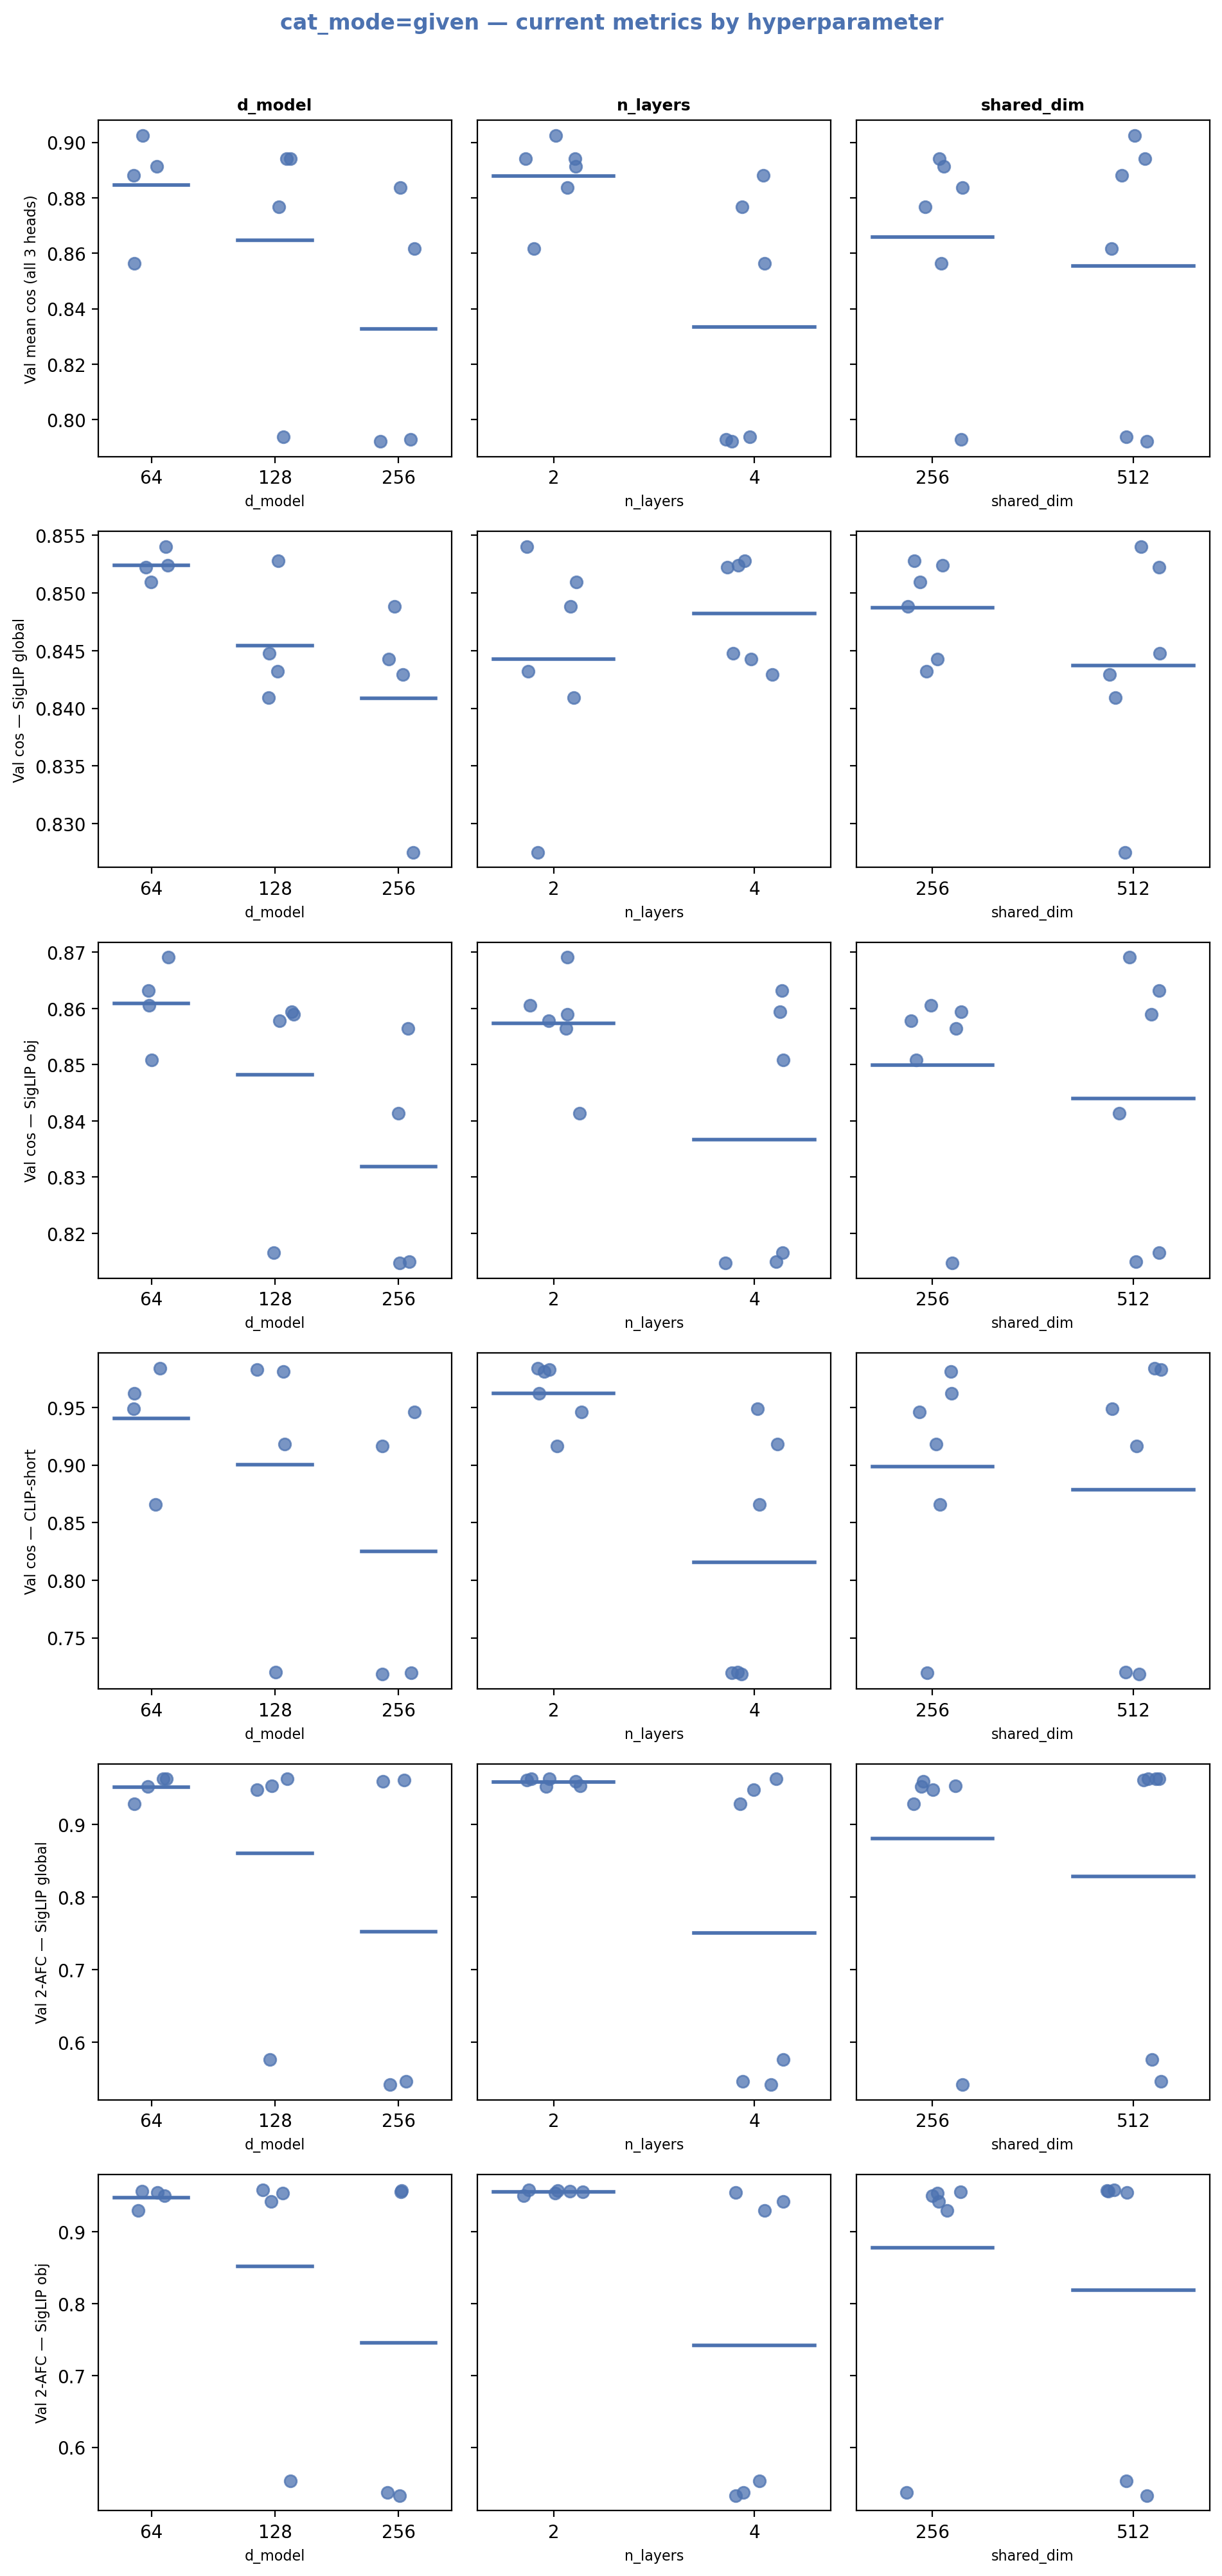

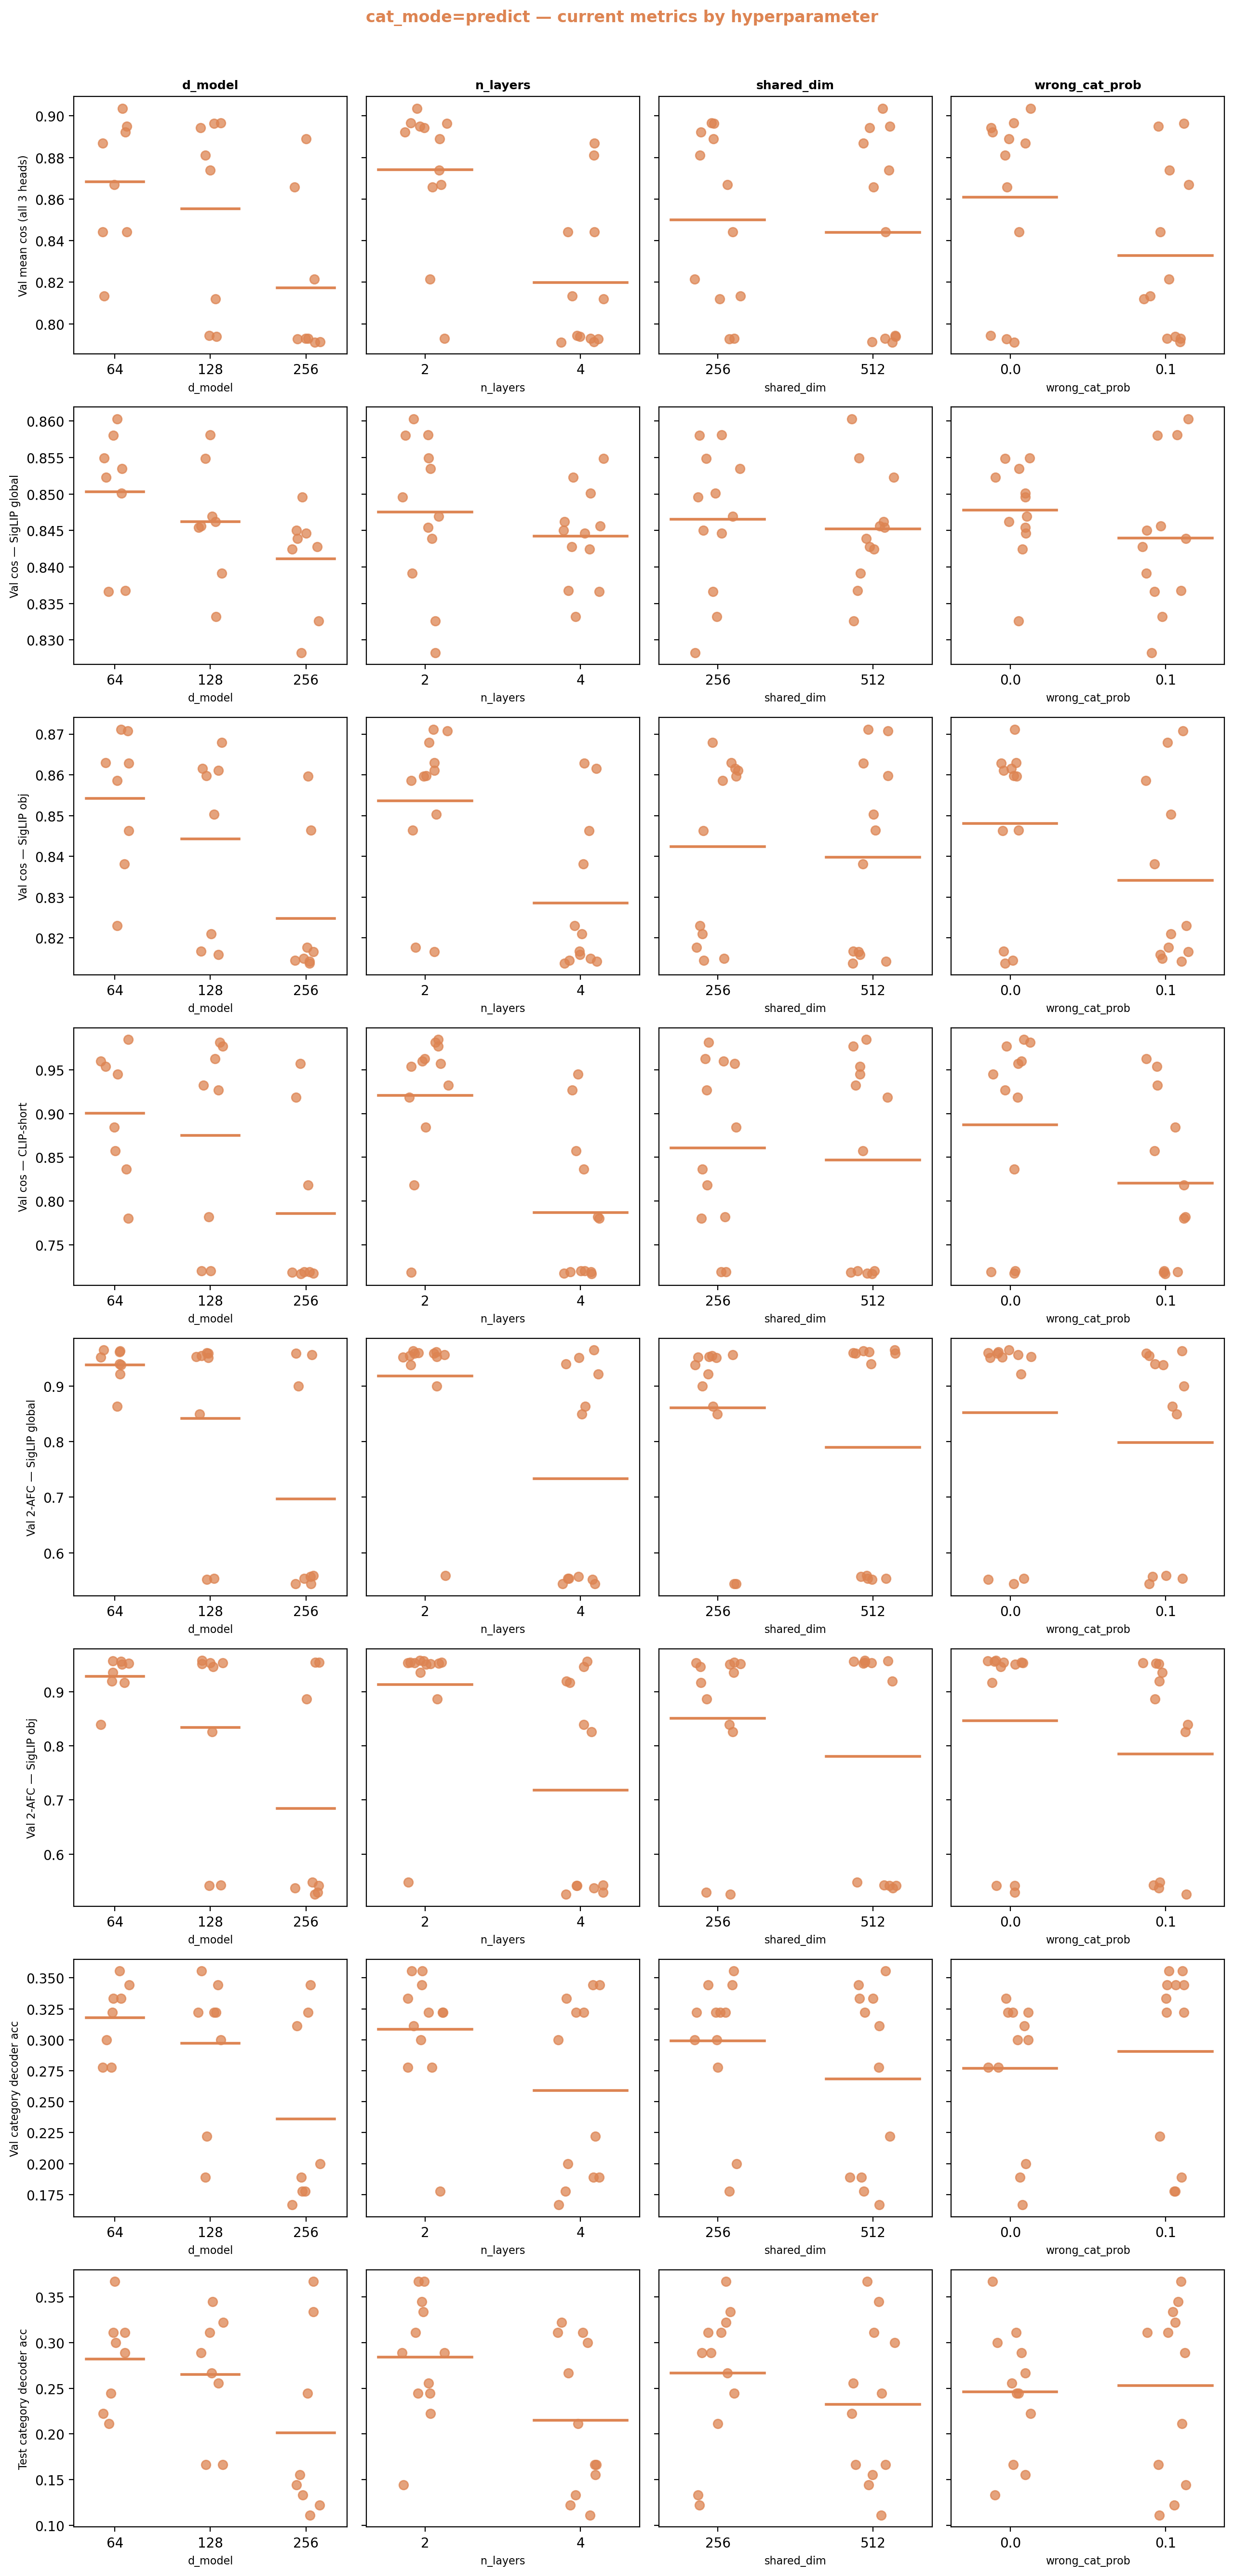

In [14]:

BASE_METRICS = [
    ('val_mean_cos',           'Val mean cos (all 3 heads)'),
    ('val_cos_siglip_global',  'Val cos — SigLIP global'),
    ('val_cos_siglip_obj',     'Val cos — SigLIP obj'),
    ('val_cos_clip',           'Val cos — CLIP-short'),
    ('val_2afc_siglip_global', 'Val 2-AFC — SigLIP global'),
    ('val_2afc_siglip_obj',    'Val 2-AFC — SigLIP obj'),
    ('classifier_val_acc',     'Val category decoder acc'),
    ('classifier_test_acc',    'Test category decoder acc'),
]

NUMERIC_AXES_BASE = ['d_model', 'n_layers', 'shared_dim', 'wrong_cat_prob']
modes = sorted(df['cat_mode'].dropna().unique())
mode_color = {'given': '#4C72B0', 'predict': '#DD8452'}
rng = np.random.default_rng(0)

for mode in modes:
    df_mode = df[df['cat_mode'] == mode]
    color = mode_color.get(mode, 'grey')

    # Important: choose metrics/axes per mode, not globally. Otherwise the given
    # baseline gets empty category-decoder rows inherited from predict runs.
    metrics = [(m, l) for m, l in BASE_METRICS if m in df_mode.columns and df_mode[m].notna().any()]
    numeric_axes = [a for a in NUMERIC_AXES_BASE if a in df_mode.columns and df_mode[a].notna().any()]

    if not metrics or not numeric_axes:
        print(f'No plottable metrics for cat_mode={mode}')
        continue

    fig, axes = plt.subplots(len(metrics), len(numeric_axes),
                             figsize=(3.2 * len(numeric_axes), 3.3 * len(metrics)),
                             sharey='row', squeeze=False)

    for mi, (metric, ylabel) in enumerate(metrics):
        for ai, axis_col in enumerate(numeric_axes):
            ax = axes[mi, ai]
            levels = sorted(df_mode[axis_col].dropna().unique())
            for lvl_i, lvl in enumerate(levels):
                vals = df_mode[df_mode[axis_col] == lvl][metric].dropna().values
                if not len(vals):
                    continue
                jitter = rng.uniform(-0.15, 0.15, len(vals))
                ax.scatter(np.full(len(vals), lvl_i) + jitter, vals,
                           color=color, alpha=0.75, s=45)
                ax.plot([lvl_i - 0.3, lvl_i + 0.3],
                        [vals.mean(), vals.mean()], color=color, lw=2)
            ax.set_xticks(range(len(levels)))
            ax.set_xticklabels([str(l) for l in levels])
            ax.set_xlabel(axis_col, fontsize=8)
            if ai == 0:
                ax.set_ylabel(ylabel, fontsize=8)
            if mi == 0:
                ax.set_title(axis_col, fontsize=9, fontweight='bold')

    fig.suptitle(f'cat_mode={mode} — current metrics by hyperparameter',
                 fontweight='bold', color=color, y=1.01)
    plt.tight_layout()
    plt.show()


## given vs predict: head-by-head comparison

/tmp/ipykernel_61373/339277394.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(groups))


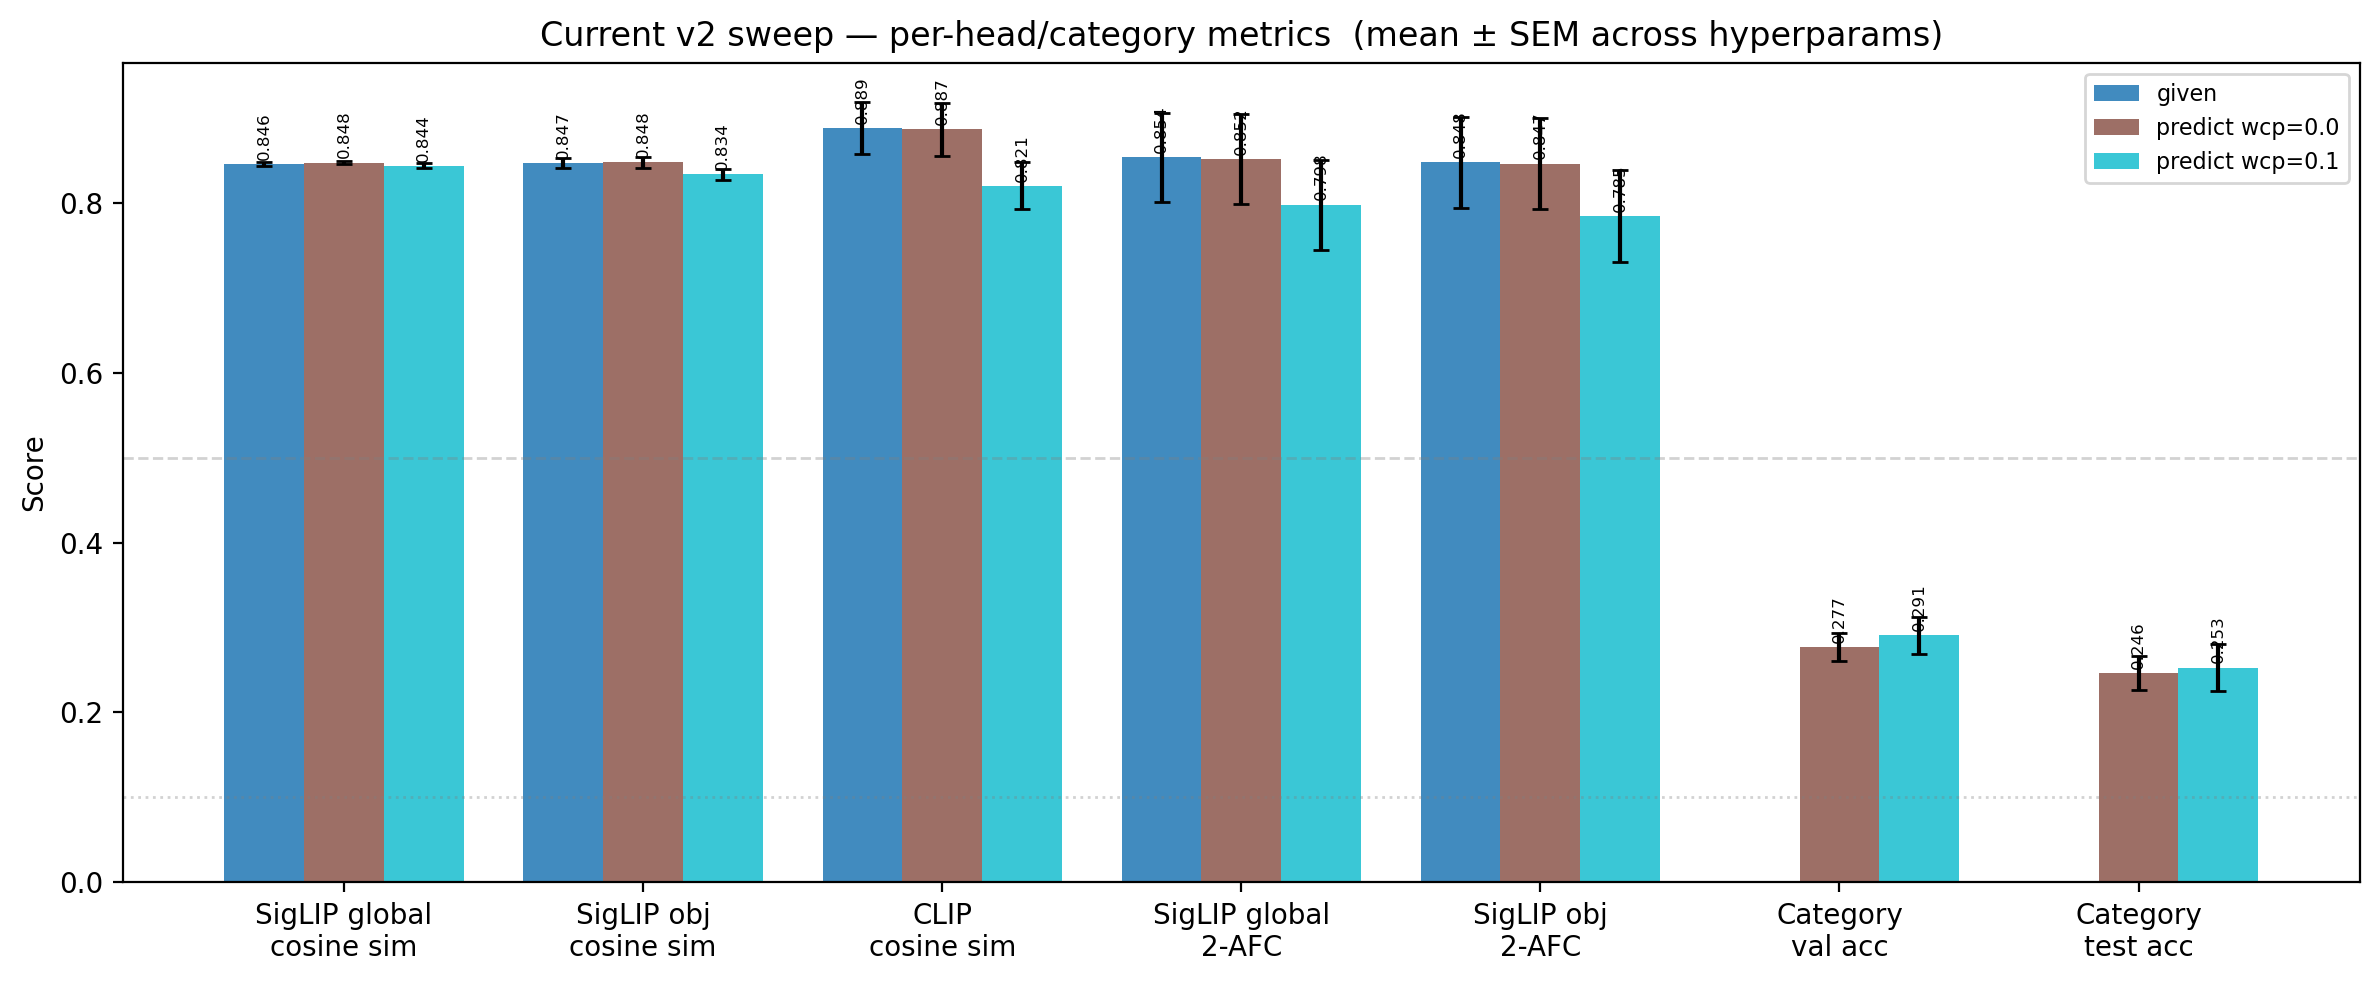


Category decoder accuracy:


classifier_val_acc           classifier_test_acc          
                              mean       sem                mean       sem
group                                                                     
given                          NaN       NaN                 NaN       NaN
predict wcp=0.0           0.276852  0.016832            0.246296  0.019812
predict wcp=0.1           0.290741  0.021574            0.252778  0.027358

In [15]:

head_metrics = [
    ('val_cos_siglip_global',  'SigLIP global\ncosine sim'),
    ('val_cos_siglip_obj',     'SigLIP obj\ncosine sim'),
    ('val_cos_clip',           'CLIP\ncosine sim'),
    ('val_2afc_siglip_global', 'SigLIP global\n2-AFC'),
    ('val_2afc_siglip_obj',    'SigLIP obj\n2-AFC'),
    ('classifier_val_acc',     'Category\nval acc'),
    ('classifier_test_acc',    'Category\ntest acc'),
]
head_metrics = [(m, l) for m, l in head_metrics if m in df.columns and df[m].notna().any()]

plot_df = df.copy()
plot_df['group'] = plot_df.apply(
    lambda r: f"{r['cat_mode']}" if pd.isna(r.get('wrong_cat_prob')) else f"{r['cat_mode']} wcp={r['wrong_cat_prob']:.1f}",
    axis=1,
)
groups = sorted(plot_df['group'].unique())
x = np.arange(len(head_metrics))
width = min(0.8 / max(1, len(groups)), 0.28)
colors = plt.cm.get_cmap('tab10', len(groups))

fig, ax = plt.subplots(figsize=(12, 5))
for i, group in enumerate(groups):
    sub = plot_df[plot_df['group'] == group]
    means = [sub[m].mean() for m, _ in head_metrics]
    sems = [sub[m].sem() for m, _ in head_metrics]
    offset = (i - (len(groups)-1)/2) * width
    bars = ax.bar(x + offset, means, width, yerr=sems, capsize=3,
                  label=group, color=colors(i), alpha=0.85)
    for bar, v in zip(bars, means):
        if np.isfinite(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([l for _, l in head_metrics])
ax.set_ylabel('Score')
ax.set_title('Current v2 sweep — per-head/category metrics  (mean ± SEM across hyperparams)')
ax.legend(fontsize=8)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.35)
ax.axhline(0.1, color='grey', lw=1, ls=':', alpha=0.35)
plt.tight_layout()
plt.show()

if 'classifier_val_acc' in df.columns:
    cat_acc = plot_df.groupby('group')[['classifier_val_acc', 'classifier_test_acc']].agg(['mean', 'sem'])
    print('\nCategory decoder accuracy:')
    display(cat_acc)


## Effect of d_model

/tmp/ipykernel_61373/180137469.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(dm_metrics))


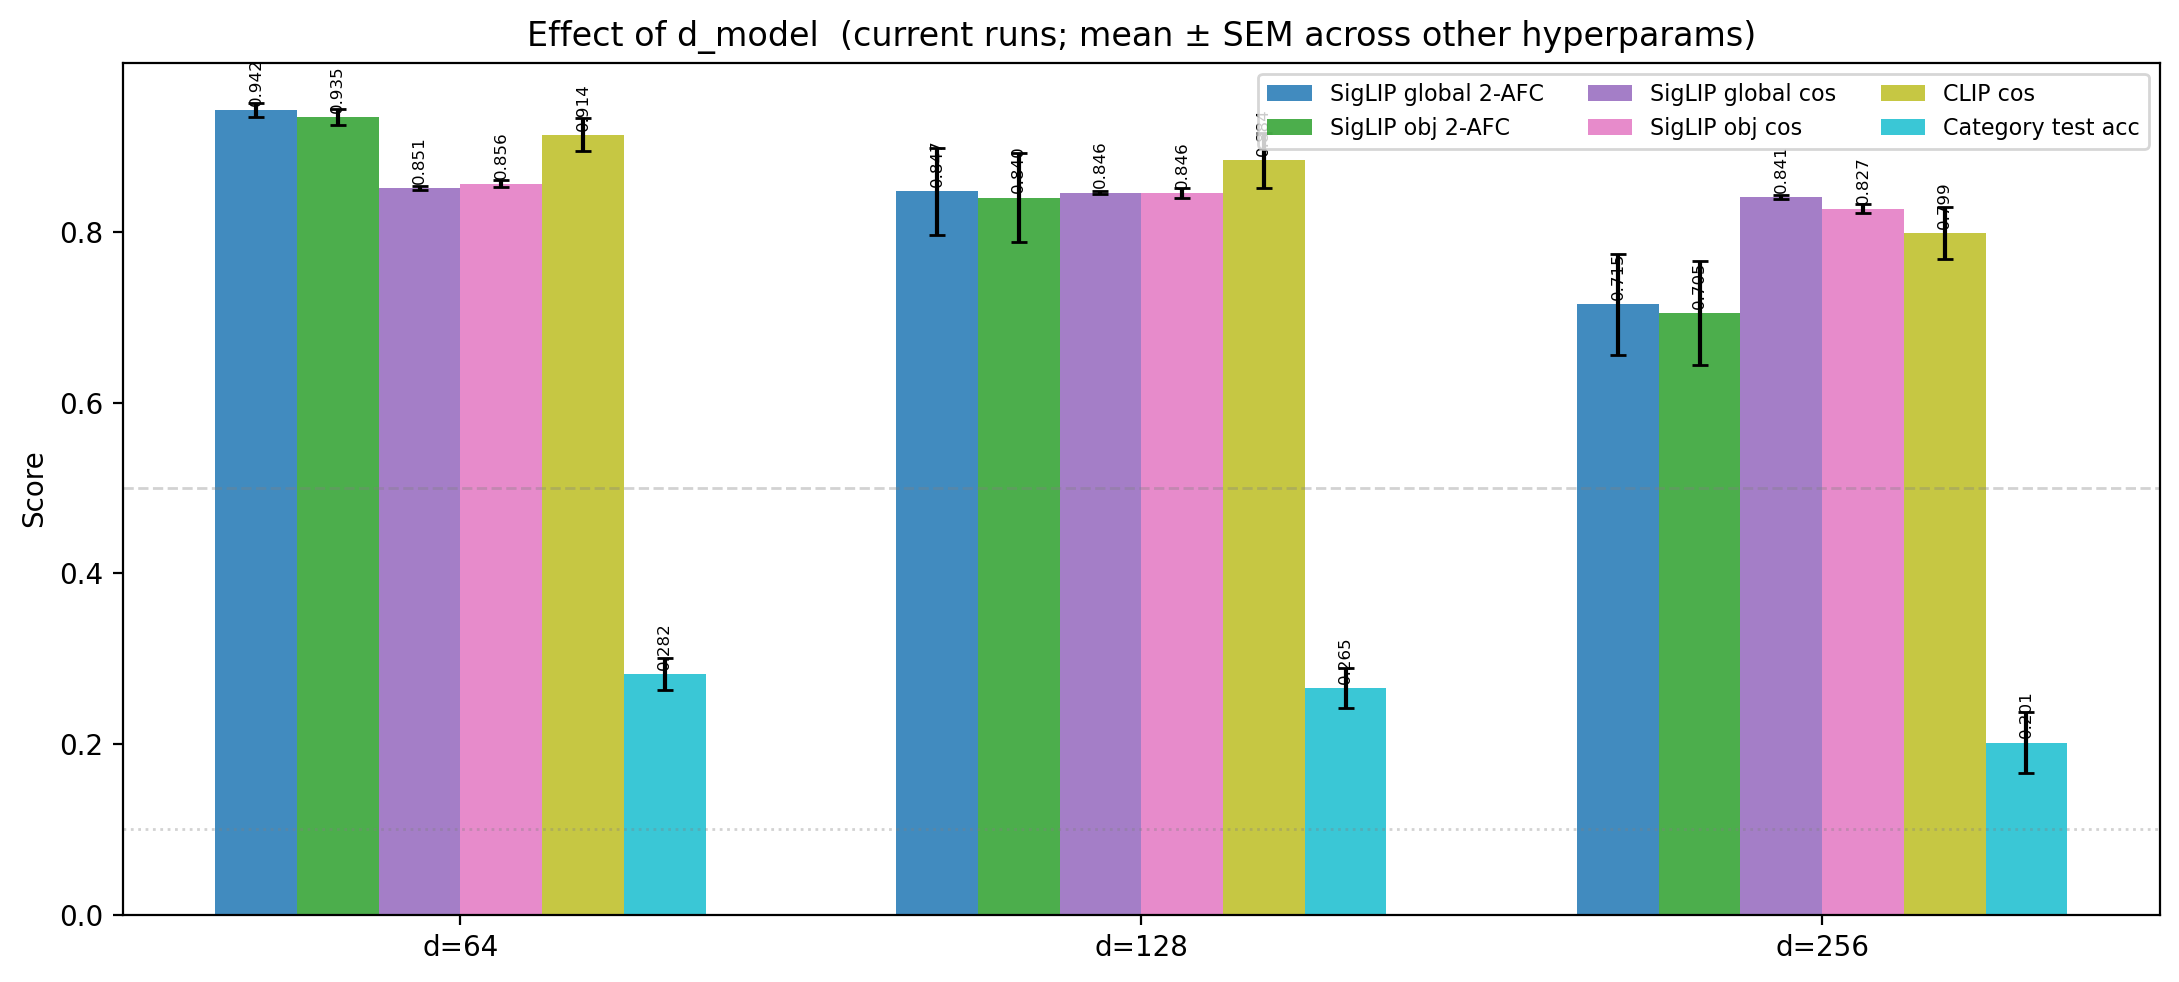

In [16]:

dm_metrics = [
    ('val_2afc_siglip_global', 'SigLIP global 2-AFC'),
    ('val_2afc_siglip_obj',    'SigLIP obj 2-AFC'),
    ('val_cos_siglip_global',  'SigLIP global cos'),
    ('val_cos_siglip_obj',     'SigLIP obj cos'),
    ('val_cos_clip',           'CLIP cos'),
    ('classifier_test_acc',    'Category test acc'),
]
dm_metrics = [(m, l) for m, l in dm_metrics if m in df.columns and df[m].notna().any()]

dm_labels = sorted(df['d_model'].dropna().unique())
x = np.arange(len(dm_labels))
width = 0.12

cmap = plt.cm.get_cmap('tab10', len(dm_metrics))
fig, ax = plt.subplots(figsize=(11, 5))
offsets = np.linspace(-(len(dm_metrics)-1)/2, (len(dm_metrics)-1)/2, len(dm_metrics)) * width

for off, (metric, label), color in zip(offsets, dm_metrics, [cmap(i) for i in range(len(dm_metrics))]):
    means = [df[df['d_model'] == d][metric].mean() for d in dm_labels]
    sems  = [df[df['d_model'] == d][metric].sem()  for d in dm_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3,
                   label=label, color=color, alpha=0.85)
    for bar, v in zip(bars, means):
        if np.isfinite(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f'd={int(d)}' for d in dm_labels])
ax.set_ylabel('Score')
ax.set_title('Effect of d_model  (current runs; mean ± SEM across other hyperparams)')
ax.legend(fontsize=8, ncol=3)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.35)
ax.axhline(0.1, color='grey', lw=1, ls=':', alpha=0.35)
plt.tight_layout()
plt.show()


## Val vs test generalisation

/tmp/ipykernel_61373/973228753.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(groups))


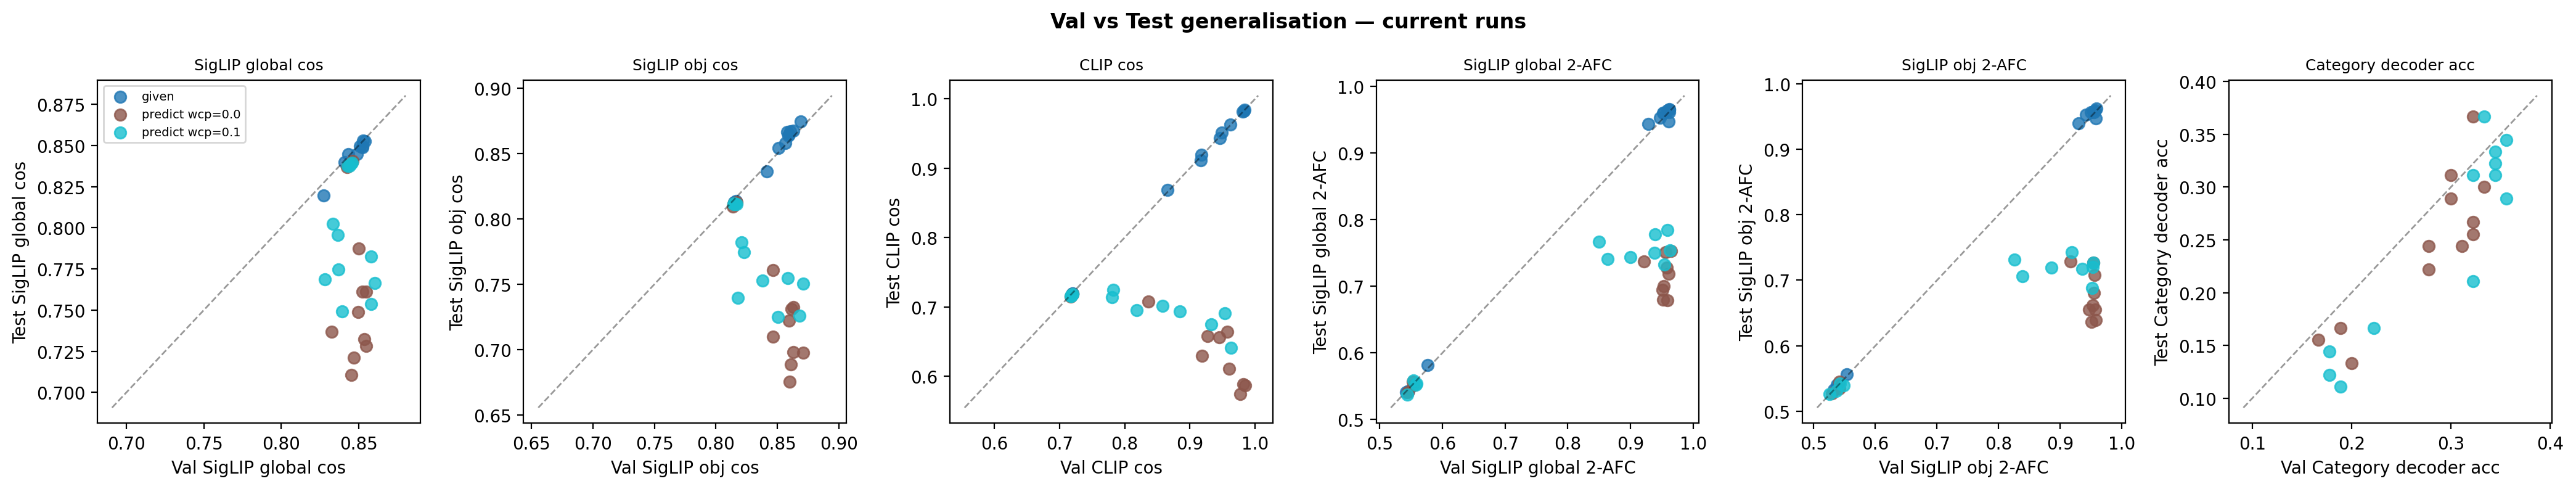

In [17]:

if has_test:
    pairs = [
        ('val_cos_siglip_global',  'test_cos_siglip_global',  'SigLIP global cos'),
        ('val_cos_siglip_obj',     'test_cos_siglip_obj',     'SigLIP obj cos'),
        ('val_cos_clip',           'test_cos_clip',           'CLIP cos'),
        ('val_2afc_siglip_global', 'test_2afc_siglip_global', 'SigLIP global 2-AFC'),
        ('val_2afc_siglip_obj',    'test_2afc_siglip_obj',    'SigLIP obj 2-AFC'),
        ('classifier_val_acc',     'classifier_test_acc',     'Category decoder acc'),
    ]
    pairs = [(v, t, l) for v, t, l in pairs if v in df.columns and t in df.columns and df[t].notna().any()]
    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 4), squeeze=False)
    axes = axes.ravel()
    plot_df = df.copy()
    plot_df['group'] = plot_df.apply(
        lambda r: f"{r['cat_mode']}" if pd.isna(r.get('wrong_cat_prob')) else f"{r['cat_mode']} wcp={r['wrong_cat_prob']:.1f}",
        axis=1,
    )
    groups = sorted(plot_df['group'].unique())
    colors = plt.cm.get_cmap('tab10', len(groups))
    for ax, (vcol, tcol, title) in zip(axes, pairs):
        sub_all = plot_df.dropna(subset=[vcol, tcol])
        for gi, (group, grp) in enumerate(sub_all.groupby('group')):
            ax.scatter(grp[vcol], grp[tcol], color=colors(groups.index(group)),
                       label=group, s=45, alpha=0.8)
        if len(sub_all):
            lims = [min(sub_all[vcol].min(), sub_all[tcol].min()) - 0.02,
                    max(sub_all[vcol].max(), sub_all[tcol].max()) + 0.02]
            ax.plot(lims, lims, 'k--', lw=1, alpha=0.4)
        ax.set_xlabel(f'Val {title}')
        ax.set_ylabel(f'Test {title}')
        ax.set_title(title, fontsize=9)
    axes[0].legend(fontsize=7)
    fig.suptitle('Val vs Test generalisation — current runs', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Test metrics not yet available — rerun once all jobs complete.')


## Top-10 runs by val mean cosine similarity

In [18]:

top_cols = [c for c in [
    'cat_mode', 'wrong_cat_prob', 'd_model', 'n_layers', 'shared_dim',
    'epoch', 'val_mean_cos', 'val_mean_2afc',
    'val_cos_siglip_global', 'val_cos_siglip_obj', 'val_cos_clip',
    'val_2afc_siglip_global', 'val_2afc_siglip_obj',
    'classifier_val_acc', 'classifier_test_acc',
    'test_cos_siglip_global', 'test_cos_siglip_obj', 'test_cos_clip',
    'test_2afc_siglip_global', 'test_2afc_siglip_obj',
    'path',
] if c in df.columns]
display(df.sort_values('val_mean_cos', ascending=False)[top_cols].head(15).reset_index(drop=True))


,cat_mode,wrong_cat_prob,d_model,n_layers,shared_dim,epoch,val_mean_cos,val_mean_2afc,val_cos_siglip_global,val_cos_siglip_obj,...,val_2afc_siglip_global,val_2afc_siglip_obj,classifier_val_acc,classifier_test_acc,test_cos_siglip_global,test_cos_siglip_obj,test_cos_clip,test_2afc_siglip_global,test_2afc_siglip_obj,path
0,predict,0.0,64,2,512,139,0.903606,0.959176,0.854909,0.871176,...,0.961174,0.957179,0.277778,0.222222,0.728167,0.697820,0.586318,0.718727,0.655181,/home/yy3658/NeurObjectGen/checkpoints/multihe...
1,given,NaN,64,2,512,144,0.902382,0.959551,0.854023,0.869082,...,0.962297,0.956804,NaN,NaN,0.852560,0.874363,0.984504,0.964919,0.959551,/home/yy3658/NeurObjectGen/checkpoints/multihe...
2,predict,0.0,128,2,256,144,0.896553,0.952934,0.846915,0.861133,...,0.952684,0.953184,0.300000,0.288889,0.721025,0.688576,0.588651,0.700000,0.661423,/home/yy3658/NeurObjectGen/checkpoints/multihe...
3,predict,0.1,128,2,256,183,0.896247,0.952809,0.858108,0.867941,...,0.953933,0.951685,0.322222,0.311111,0.753698,0.725723,0.640554,0.732335,0.688639,/home/yy3658/NeurObjectGen/checkpoints/multihe...
4,predict,0.1,64,2,512,158,0.895013,0.957928,0.860317,0.870829,...,0.963171,0.952684,0.333333,0.366667,0.766531,0.750257,0.690340,0.753683,0.720599,/home/yy3658/NeurObjectGen/checkpoints/multihe...
5,given,NaN,128,2,512,138,0.894166,0.960300,0.840935,0.858983,...,0.962297,0.958302,NaN,NaN,0.840007,0.863876,0.982309,0.966167,0.961923,/home/yy3658/NeurObjectGen/checkpoints/multihe...
6,predict,0.0,128,2,512,114,0.894157,0.958302,0.845426,0.859729,...,0.959176,0.957428,0.322222,0.255556,0.710676,0.675555,0.574507,0.678777,0.639076,/home/yy3658/NeurObjectGen/checkpoints/multihe...
7,given,NaN,128,2,256,153,0.894030,0.953371,0.843237,0.857811,...,0.953059,0.953683,NaN,NaN,0.844690,0.866741,0.981295,0.960424,0.957678,/home/yy3658/NeurObjectGen/checkpoints/multihe...
8,predict,0.0,64,2,256,176,0.892192,0.951373,0.853469,0.862929,...,0.951810,0.950936,0.277778,0.244444,0.732301,0.698127,0.610711,0.679401,0.636080,/home/yy3658/NeurObjectGen/checkpoints/multihe...
9,given,NaN,64,2,256,181,0.891328,0.951186,0.850967,0.860549,...,0.952310,0.950062,NaN,NaN,0.849741,0.867003,0.963175,0.959800,0.956180,/home/yy3658/NeurObjectGen/checkpoints/multihe...


## Best config — all metrics summary bar chart

/tmp/ipykernel_61373/3069984498.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors   = plt.cm.get_cmap('tab10', len(BEST_METRICS))(range(len(BEST_METRICS)))


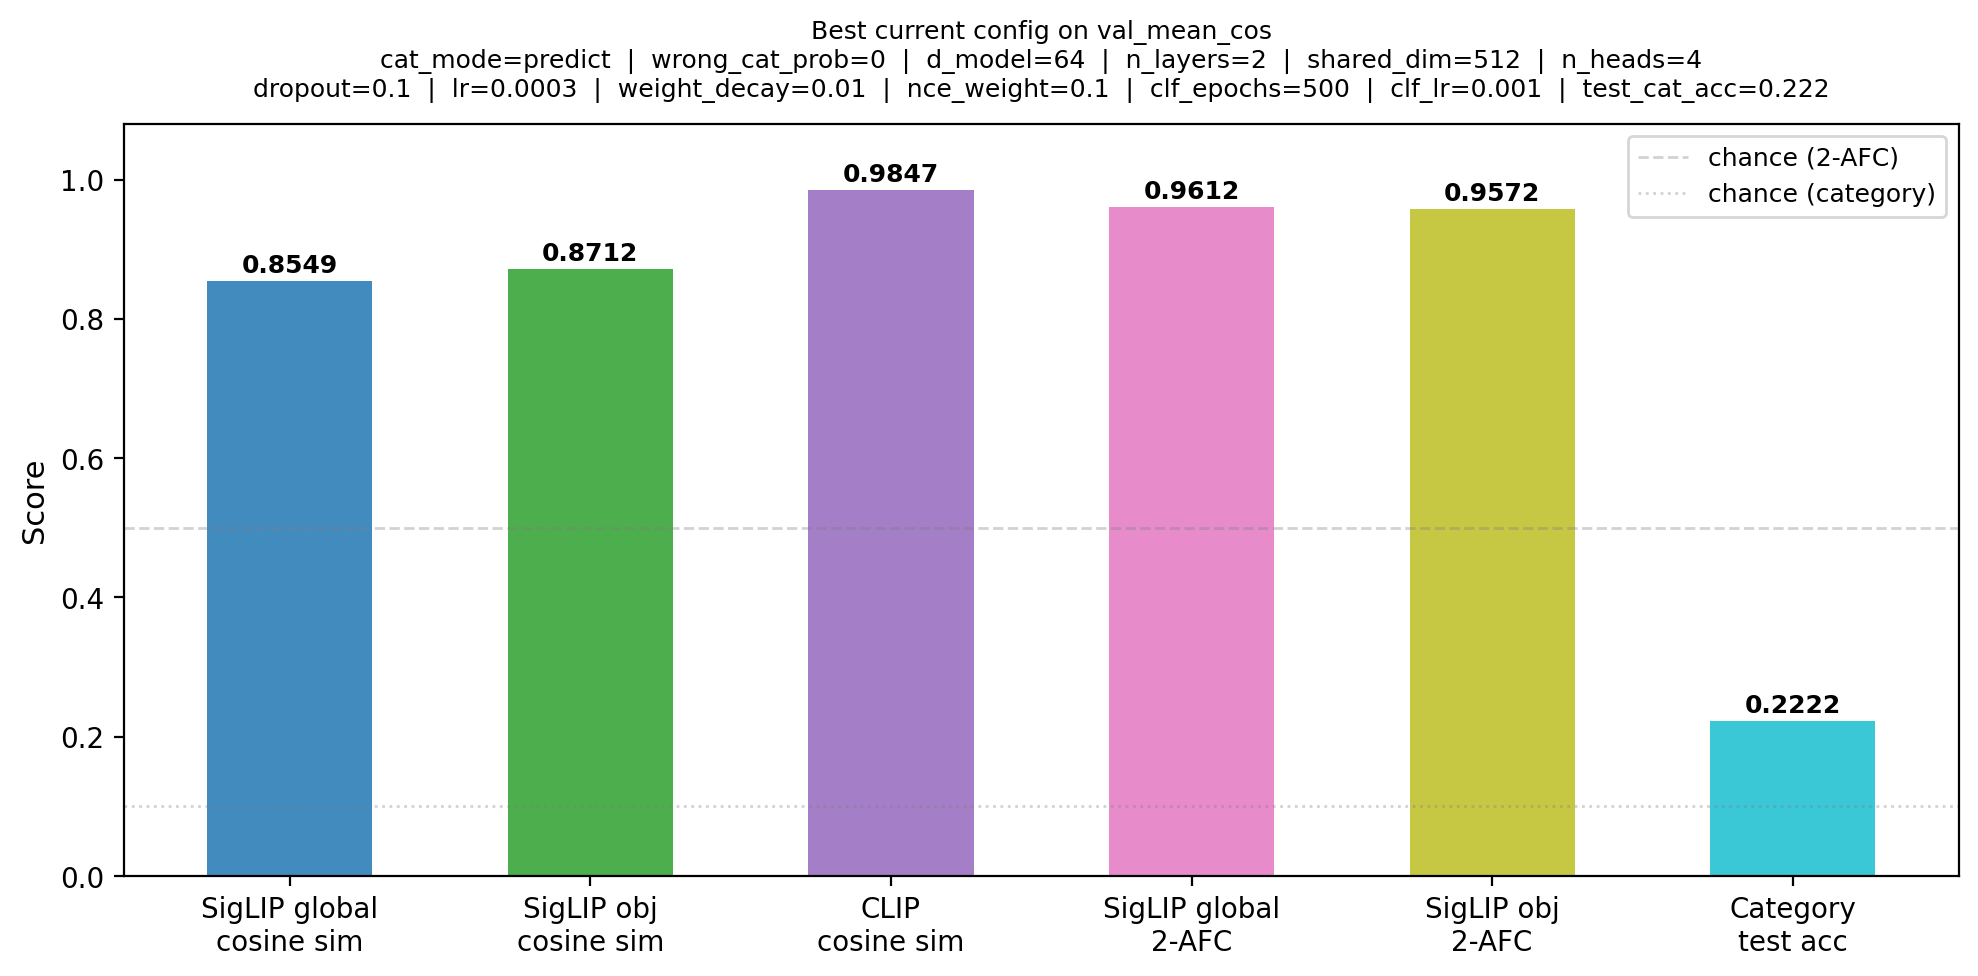

In [19]:

BEST_METRICS = [
    ('val_cos_siglip_global',  'SigLIP global\ncosine sim'),
    ('val_cos_siglip_obj',     'SigLIP obj\ncosine sim'),
    ('val_cos_clip',           'CLIP\ncosine sim'),
    ('val_2afc_siglip_global', 'SigLIP global\n2-AFC'),
    ('val_2afc_siglip_obj',    'SigLIP obj\n2-AFC'),
    ('classifier_test_acc',    'Category\ntest acc'),
]
BEST_METRICS = [(m, l) for m, l in BEST_METRICS if m in df.columns and df[m].notna().any()]

best_row = df.sort_values('val_mean_cos', ascending=False).iloc[0]
vals     = [float(best_row[m]) for m, _ in BEST_METRICS]
labels   = [l for _, l in BEST_METRICS]
colors   = plt.cm.get_cmap('tab10', len(BEST_METRICS))(range(len(BEST_METRICS)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.55)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.35, label='chance (2-AFC)')
ax.axhline(0.1, color='grey', lw=1, ls=':', alpha=0.35, label='chance (category)')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=9)

def _fmt(k, row):
    v = row[k]
    try:
        fv = float(v)
        return f'{k}={int(fv) if fv == int(fv) else fv:.4g}'
    except Exception:
        return f'{k}={v}'

hp_keys1 = ['cat_mode', 'wrong_cat_prob', 'd_model', 'n_layers', 'shared_dim', 'n_heads']
hp_keys2 = ['dropout', 'lr', 'weight_decay', 'nce_weight', 'clf_epochs', 'clf_lr']
hp_line1 = '  |  '.join(_fmt(k, best_row) for k in hp_keys1 if k in best_row and not pd.isna(best_row[k]))
hp_line2 = '  |  '.join(_fmt(k, best_row) for k in hp_keys2 if k in best_row and not pd.isna(best_row[k]))
if 'classifier_test_acc' in best_row and not pd.isna(best_row['classifier_test_acc']):
    hp_line2 += f'  |  test_cat_acc={float(best_row["classifier_test_acc"]):.3f}'
ax.set_title(f'Best current config on val_mean_cos\n{hp_line1}\n{hp_line2}', fontsize=9, pad=10)
plt.tight_layout()
plt.show()


In [20]:

import json
from config_const import CACHE_DIR

CACHE_DIR.mkdir(parents=True, exist_ok=True)

for keys, df_group in df.groupby(['cat_mode', 'wrong_cat_prob'], dropna=False):
    mode, wcp = keys
    if df_group.empty:
        continue
    best_row = df_group.sort_values('val_mean_cos', ascending=False).iloc[0]
    config = {
        'model':      'multihead_v2',
        'dataset':    'hvm',
        'cat_mode':   mode,
        'wrong_cat_prob': None if pd.isna(wcp) else float(wcp),
        'val_mean_cos':  float(best_row['val_mean_cos']),
        'val_mean_2afc': float(best_row.get('val_mean_2afc', float('nan'))),
        'classifier_val_acc': float(best_row.get('classifier_val_acc', float('nan'))),
        'classifier_test_acc': float(best_row.get('classifier_test_acc', float('nan'))),
        'checkpoint': best_row['path'],
        'd_model':    int(best_row['d_model']),
        'n_heads':    int(best_row['n_heads']),
        'n_layers':   int(best_row['n_layers']),
        'shared_dim': int(best_row['shared_dim']),
        'dropout':    float(best_row['dropout']),
        'lr':         float(best_row['lr']),
        'weight_decay':           float(best_row['weight_decay']),
        'nce_weight':             float(best_row['nce_weight']),
        'loss_weight_siglip':     float(best_row['loss_weight_siglip']),
        'loss_weight_siglip_obj': float(best_row['loss_weight_siglip_obj']),
        'loss_weight_clip':       float(best_row['loss_weight_clip']),
    }
    suffix = mode if pd.isna(wcp) else f'{mode}_wcp{float(wcp):.1f}'
    out_path = CACHE_DIR / f'best_hvm_multihead_v2_{suffix}_config.json'
    with open(out_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f'Saved {suffix} -> {out_path}')
    print(f"  val_mean_cos={config['val_mean_cos']:.4f}  d_model={config['d_model']}  n_layers={config['n_layers']}  shared_dim={config['shared_dim']}  wrong_cat_prob={config['wrong_cat_prob']}")
    print(f"  {config['checkpoint']}")
    print()


Saved given -> /home/yy3658/NeurObjectGen/cache/best_hvm_multihead_v2_given_config.json
  val_mean_cos=0.9024  d_model=64  n_layers=2  shared_dim=512  wrong_cat_prob=None
  /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_cmgiven/best.pt

Saved predict_wcp0.0 -> /home/yy3658/NeurObjectGen/cache/best_hvm_multihead_v2_predict_wcp0.0_config.json
  val_mean_cos=0.9036  d_model=64  n_layers=2  shared_dim=512  wrong_cat_prob=0.0
  /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_cmpredict_cle500_clr0.001_cwd0.01_wcp0.0/best.pt

Saved predict_wcp0.1 -> /home/yy3658/NeurObjectGen/cache/best_hvm_multihead_v2_predict_wcp0.1_config.json
  val_mean_cos=0.8962  d_model=128  n_layers=2  shared_dim=256  wrong_cat_prob=0.1
  /home/yy3658/NeurObjectGen/checkpoints/multihead_v2

## Per-category cosine similarity — all three heads (test set)
Loads the best checkpoint and runs inference on the 90 held-out test stimuli.

Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.59it/s]
/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


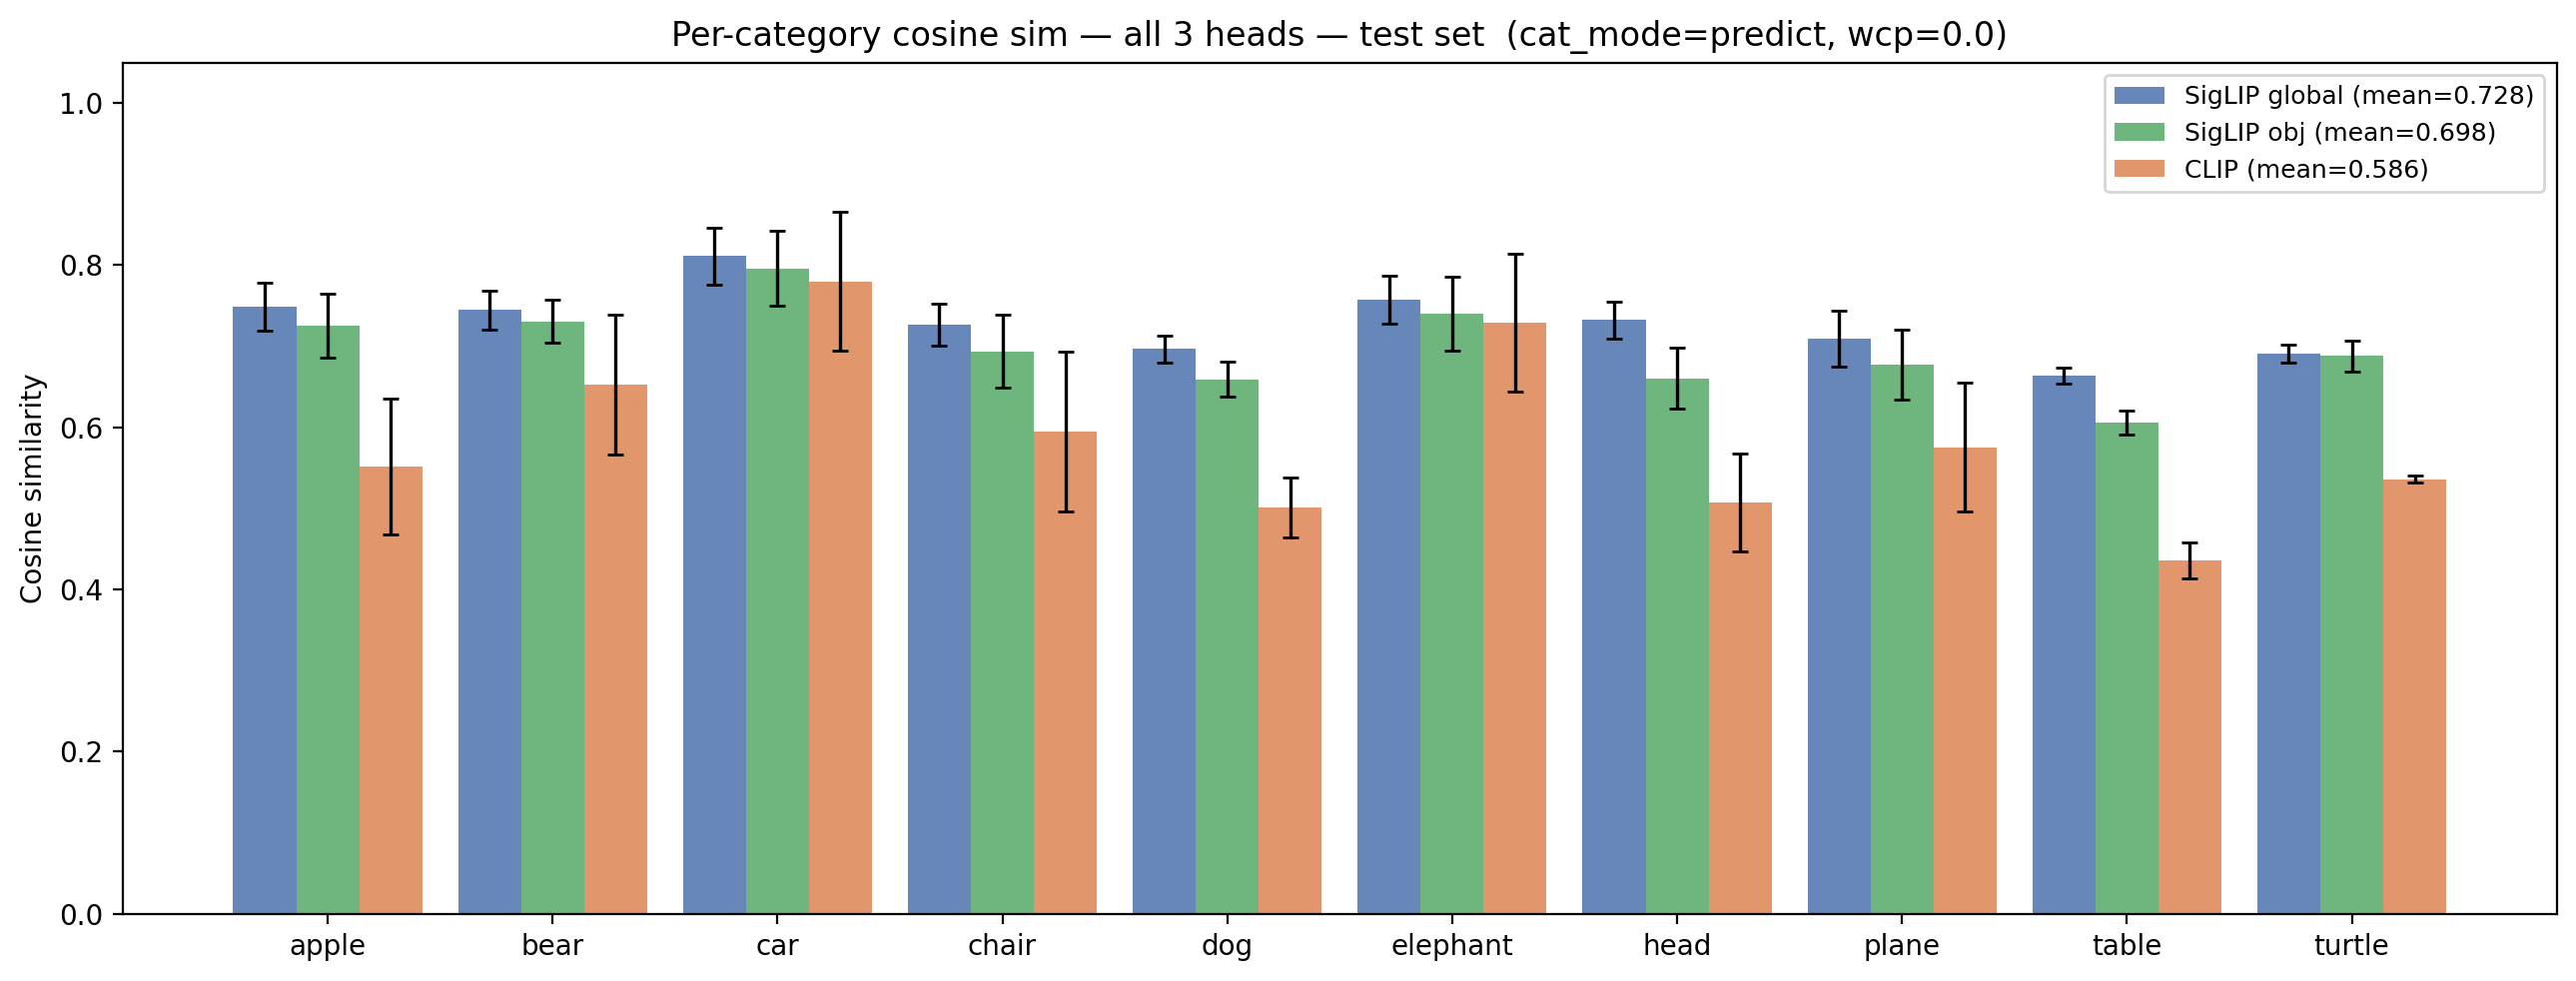

In [21]:
import torch
import torch.nn.functional as F
from config_const import (
    SEED, HVM_CATEGORIES, HVM_N_VAR, HVM_N_STIMULI,
    HVM_SIGLIP_EMBEDDINGS_PATH, HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, HVM_CLIP_EMBEDS_PATH,
)
from data_utils.hvm_loader import _load_hvm_neural, _category_stratified_split
from encoders import MultiHeadTransformerV2

best_row = df.sort_values('val_mean_cos', ascending=False).iloc[0]

# ── load data
rsp, _, _ = _load_hvm_neural()
neural_t     = torch.from_numpy(rsp).float()
siglip_t     = torch.load(HVM_SIGLIP_EMBEDDINGS_PATH,     weights_only=True)
siglip_obj_t = F.normalize(torch.load(HVM_OBJ_SIGLIP_EMBEDDINGS_PATH, weights_only=True), dim=-1)
clip_t       = F.normalize(torch.load(HVM_CLIP_EMBEDS_PATH, weights_only=True), dim=-1)
cat_indices  = torch.arange(HVM_N_STIMULI) // HVM_N_VAR

_, _, test_idx_np = _category_stratified_split(seed=SEED)
test_idx    = torch.from_numpy(test_idx_np).long()
neural_test = neural_t[test_idx].permute(0, 2, 1)   # (90, T, N)
gt_sg       = siglip_t[test_idx]
gt_so       = siglip_obj_t[test_idx]
gt_clip     = clip_t[test_idx]
test_cats   = cat_indices[test_idx]

# ── build & load model
m = MultiHeadTransformerV2(
    n_neurons=neural_t.shape[1],
    d_model=int(best_row['d_model']),
    n_heads=int(best_row['n_heads']),
    n_layers=int(best_row['n_layers']),
    shared_dim=int(best_row['shared_dim']),
    dropout=float(best_row['dropout']),
    n_categories=10,
)
ckpt = torch.load(best_row['path'], weights_only=False, map_location='cpu')
m.load_state_dict(ckpt['model_state'])
m.eval()

cat_mode = str(best_row.get('cat_mode', 'given'))
with torch.no_grad():
    pred = m(neural_test, test_cats, cat_mode=cat_mode)

pred_sg   = pred['siglip_global']
pred_so   = pred['siglip_obj']
pred_clip = pred['clip']

def per_cat(pred_t, gt_t):
    cos = F.cosine_similarity(pred_t, gt_t, dim=-1)
    means = [cos[test_cats == i].mean().item() for i in range(len(HVM_CATEGORIES))]
    sems  = [(cos[test_cats == i].std() /
              (test_cats == i).sum().float().sqrt()).item()
             for i in range(len(HVM_CATEGORIES))]
    return cos.mean().item(), means, sems

ov_sg,   m_sg,   s_sg   = per_cat(pred_sg,   gt_sg)
ov_so,   m_so,   s_so   = per_cat(pred_so,   gt_so)
ov_clip, m_clip, s_clip = per_cat(pred_clip, gt_clip)

x = np.arange(len(HVM_CATEGORIES))
width = 0.28
fig, ax = plt.subplots(figsize=(13, 5))
for i, (m_vals, s_vals, label, color, ov) in enumerate([
    (m_sg,   s_sg,   'SigLIP global', '#4C72B0', ov_sg),
    (m_so,   s_so,   'SigLIP obj',    '#55A868', ov_so),
    (m_clip, s_clip, 'CLIP',          '#DD8452', ov_clip),
]):
    offset = (i - 1) * width
    ax.bar(x + offset, m_vals, width, yerr=s_vals, capsize=3,
           label=f'{label} (mean={ov:.3f})', color=color, alpha=0.85,
           error_kw=dict(lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(HVM_CATEGORIES)
ax.set_ylabel('Cosine similarity')
ax.set_title(f'Per-category cosine sim — all 3 heads — test set  (cat_mode={cat_mode}, wcp={best_row.get("wrong_cat_prob", np.nan)})')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## Per-category classification accuracy (predict mode)
Only populated when the best run used `cat_mode=predict`.

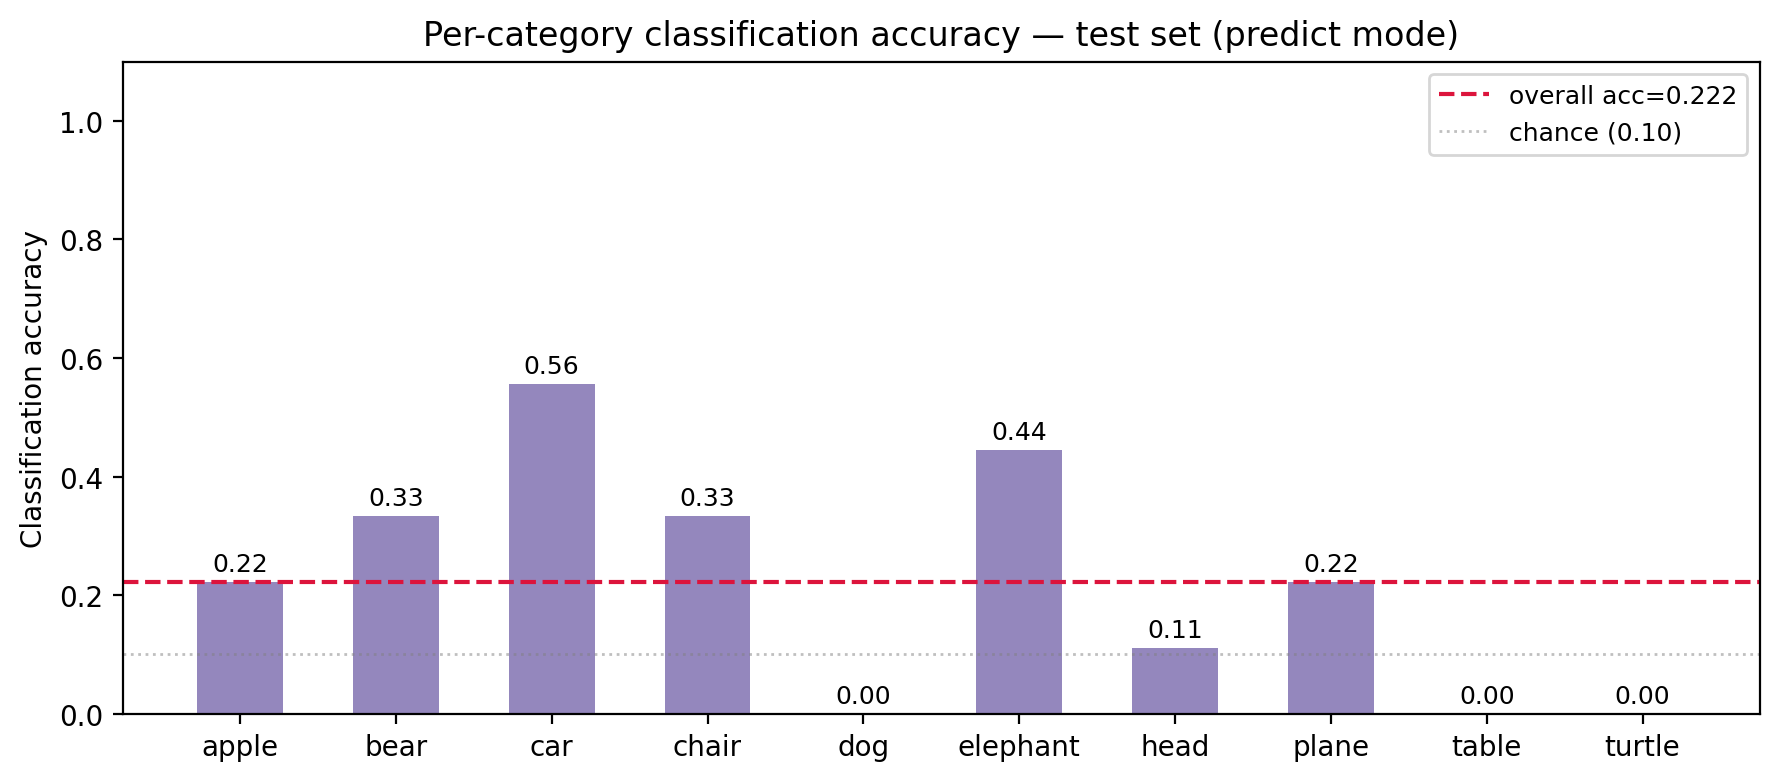

In [23]:
if cat_mode == 'predict' and pred['cat_logits'] is not None:
    cat_preds = pred['cat_logits'].argmax(-1)
    correct   = (cat_preds == test_cats).float()
    per_cat_acc = [correct[test_cats == i].mean().item() for i in range(len(HVM_CATEGORIES))]
    overall_acc = correct.mean().item()

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(HVM_CATEGORIES, per_cat_acc, color='#8172B2', alpha=0.85, width=0.55)
    for bar, v in zip(bars, per_cat_acc):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(overall_acc, color='crimson', lw=1.5, ls='--',
               label=f'overall acc={overall_acc:.3f}')
    ax.axhline(0.1, color='grey', lw=1, ls=':', alpha=0.5, label='chance (0.10)')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Classification accuracy')
    ax.set_title('Per-category classification accuracy — test set (predict mode)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Cat classification accuracy only available for cat_mode=predict.')